# 🏠 House Price Prediction in India using Machine Learning

### Major Internship Project

---

## 📌 Project Objective

The objective of this project is to develop a Machine Learning Regression model capable of predicting house prices in India based on different property features such as area, location, number of bedrooms, bathrooms, and other relevant characteristics.

This project includes complete data preprocessing, exploratory data analysis (EDA), feature engineering, model building, model evaluation, and business insights.

---

**Project Type:** Major Project

**Domain:** Machine Learning

**Problem Type:** Regression

**Tools & Technologies:** Python, Pandas, NumPy, Matplotlib, Seaborn, Scikit-Learn, Google Colab


# 📚 Import Required Libraries

In [1]:
# ==========================================================
# Import Required Libraries
# ==========================================================

# Data Manipulation
import pandas as pd
import numpy as np

# Data Visualization
import matplotlib.pyplot as plt
import seaborn as sns

# Ignore Warning Messages
import warnings
warnings.filterwarnings('ignore')

# Display Settings
pd.set_option('display.max_columns', None)
pd.set_option('display.max_rows', 100)

# Machine Learning Utilities (will be used later)
from sklearn.model_selection import train_test_split
from sklearn.preprocessing import OneHotEncoder, StandardScaler
from sklearn.compose import ColumnTransformer
from sklearn.pipeline import Pipeline

# Regression Models
from sklearn.linear_model import LinearRegression
from sklearn.tree import DecisionTreeRegressor
from sklearn.ensemble import RandomForestRegressor

# Model Evaluation
from sklearn.metrics import (
    mean_absolute_error,
    mean_squared_error,
    r2_score
)

print("="*60)
print("✅ All Libraries Imported Successfully")
print("="*60)

✅ All Libraries Imported Successfully


# 📂 Load and Explore the Dataset


In [2]:
# ==========================================================
# Upload Dataset
# ==========================================================

from google.colab import files

uploaded = files.upload()

Saving Bengaluru_House_Data.csv to Bengaluru_House_Data.csv


In [3]:
# ==========================================================
# Load Dataset
# ==========================================================

df = pd.read_csv("Bengaluru_House_Data.csv")

print("✅ Dataset Loaded Successfully")

✅ Dataset Loaded Successfully


In [4]:
# Display first 5 rows
df.head()

,area_type,availability,location,size,society,total_sqft,bath,balcony,price
0,Super built-up Area,19-Dec,Electronic City Phase II,2 BHK,Coomee,1056,2.0,1.0,39.07
1,Plot Area,Ready To Move,Chikka Tirupathi,4 Bedroom,Theanmp,2600,5.0,3.0,120.00
2,Built-up Area,Ready To Move,Uttarahalli,3 BHK,NaN,1440,2.0,3.0,62.00
3,Super built-up Area,Ready To Move,Lingadheeranahalli,3 BHK,Soiewre,1521,3.0,1.0,95.00
4,Super built-up Area,Ready To Move,Kothanur,2 BHK,NaN,1200,2.0,1.0,51.00


# 🔍 Explore the Dataset

In [5]:
# Check number of rows and columns
df.shape

(13320, 9)

In [6]:
# Display first 5 records
df.head()

,area_type,availability,location,size,society,total_sqft,bath,balcony,price
0,Super built-up Area,19-Dec,Electronic City Phase II,2 BHK,Coomee,1056,2.0,1.0,39.07
1,Plot Area,Ready To Move,Chikka Tirupathi,4 Bedroom,Theanmp,2600,5.0,3.0,120.00
2,Built-up Area,Ready To Move,Uttarahalli,3 BHK,NaN,1440,2.0,3.0,62.00
3,Super built-up Area,Ready To Move,Lingadheeranahalli,3 BHK,Soiewre,1521,3.0,1.0,95.00
4,Super built-up Area,Ready To Move,Kothanur,2 BHK,NaN,1200,2.0,1.0,51.00


In [7]:
# Display last 5 records
df.tail()

,area_type,availability,location,size,society,total_sqft,bath,balcony,price
13315,Built-up Area,Ready To Move,Whitefield,5 Bedroom,ArsiaEx,3453,4.0,0.0,231.0
13316,Super built-up Area,Ready To Move,Richards Town,4 BHK,NaN,3600,5.0,NaN,400.0
13317,Built-up Area,Ready To Move,Raja Rajeshwari Nagar,2 BHK,Mahla T,1141,2.0,1.0,60.0
13318,Super built-up Area,18-Jun,Padmanabhanagar,4 BHK,SollyCl,4689,4.0,1.0,488.0
13319,Super built-up Area,Ready To Move,Doddathoguru,1 BHK,NaN,550,1.0,1.0,17.0


In [8]:
# Dataset information
df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 13320 entries, 0 to 13319
Data columns (total 9 columns):
 #   Column        Non-Null Count  Dtype  
---  ------        --------------  -----  
 0   area_type     13320 non-null  object 
 1   availability  13320 non-null  object 
 2   location      13319 non-null  object 
 3   size          13304 non-null  object 
 4   society       7818 non-null   object 
 5   total_sqft    13320 non-null  object 
 6   bath          13247 non-null  float64
 7   balcony       12711 non-null  float64
 8   price         13320 non-null  float64
dtypes: float64(3), object(6)
memory usage: 936.7+ KB


In [9]:
# Statistical summary of numerical columns
df.describe()

,bath,balcony,price
count,13247.000000,12711.000000,13320.000000
mean,2.692610,1.584376,112.565627
std,1.341458,0.817263,148.971674
min,1.000000,0.000000,8.000000
25%,2.000000,1.000000,50.000000
50%,2.000000,2.000000,72.000000
75%,3.000000,2.000000,120.000000
max,40.000000,3.000000,3600.000000


In [10]:
# Check missing values
df.isnull().sum()

,0
area_type,0
availability,0
location,1
size,16
society,5502
total_sqft,0
bath,73
balcony,609
price,0


In [11]:
# Check duplicate records
df.duplicated().sum()

np.int64(529)

In [12]:
# Numerical columns
numerical_cols = df.select_dtypes(include=['int64', 'float64']).columns

# Categorical columns
categorical_cols = df.select_dtypes(include=['object']).columns

print("Numerical Features:")
print(numerical_cols)

print("\nCategorical Features:")
print(categorical_cols)

Numerical Features:
Index(['bath', 'balcony', 'price'], dtype='object')

Categorical Features:
Index(['area_type', 'availability', 'location', 'size', 'society',
       'total_sqft'],
      dtype='object')


# 📊 Understanding the Dataset

In [13]:
# Display all column names
df.columns

Index(['area_type', 'availability', 'location', 'size', 'society',
       'total_sqft', 'bath', 'balcony', 'price'],
      dtype='object')

In [14]:
# Count unique values in each column
df.nunique()

,0
area_type,4
availability,81
location,1305
size,31
society,2688
total_sqft,2117
bath,19
balcony,4
price,1994


In [15]:
# Calculate missing value percentage

missing_percentage = (df.isnull().sum() / len(df)) * 100

missing_percentage.sort_values(ascending=False)

,0
society,41.306306
balcony,4.572072
bath,0.548048
size,0.120120
location,0.007508
area_type,0.000000
availability,0.000000
total_sqft,0.000000
price,0.000000


In [16]:
# Check data types
df.dtypes

,0
area_type,object
availability,object
location,object
size,object
society,object
total_sqft,object
bath,float64
balcony,float64
price,float64


In [17]:
# Display random 5 records
df.sample(5, random_state=42)

,area_type,availability,location,size,society,total_sqft,bath,balcony,price
8077,Built-up Area,Ready To Move,Banjara Layout,2 Bedroom,NaN,1050,2.0,1.0,64.8
1602,Super built-up Area,Ready To Move,Rajiv Nagar,3 BHK,PuoodSk,1690,3.0,1.0,125.0
10498,Built-up Area,Ready To Move,Hebbal,2 BHK,NaN,1100,2.0,1.0,60.0
3297,Plot Area,Ready To Move,Munnekollal,6 Bedroom,NaN,1200,4.0,2.0,110.0
8893,Built-up Area,18-Apr,Choodasandra,4 Bedroom,LGifeew,2429,3.0,1.0,210.0


# 🧹 Data Cleaning & Preprocessing

In [18]:
# Check dataset shape before removing duplicates
print("Before Removing Duplicates :", df.shape)

# Remove duplicate records
df = df.drop_duplicates()

# Check dataset shape after removing duplicates
print("After Removing Duplicates :", df.shape)

Before Removing Duplicates : (13320, 9)
After Removing Duplicates : (12791, 9)


In [19]:
# Check missing values after removing duplicates
df.isnull().sum()

,0
area_type,0
availability,0
location,1
size,16
society,5328
total_sqft,0
bath,73
balcony,605
price,0


In [20]:
# Drop society column

df = df.drop('society', axis=1)

print("Society column removed successfully.")

Society column removed successfully.


In [21]:
df.head()

,area_type,availability,location,size,total_sqft,bath,balcony,price
0,Super built-up Area,19-Dec,Electronic City Phase II,2 BHK,1056,2.0,1.0,39.07
1,Plot Area,Ready To Move,Chikka Tirupathi,4 Bedroom,2600,5.0,3.0,120.00
2,Built-up Area,Ready To Move,Uttarahalli,3 BHK,1440,2.0,3.0,62.00
3,Super built-up Area,Ready To Move,Lingadheeranahalli,3 BHK,1521,3.0,1.0,95.00
4,Super built-up Area,Ready To Move,Kothanur,2 BHK,1200,2.0,1.0,51.00


In [22]:
# Remove duplicate records

df = df.drop_duplicates()

print(df.shape)

(12752, 8)


In [23]:
df.columns

Index(['area_type', 'availability', 'location', 'size', 'total_sqft', 'bath',
       'balcony', 'price'],
      dtype='object')

In [24]:
df.isnull().sum()

,0
area_type,0
availability,0
location,1
size,16
total_sqft,0
bath,73
balcony,605
price,0


In [25]:
# Remove rows having missing values in 'location' and 'size'

df.dropna(subset=['location', 'size'], inplace=True)

# Check missing values again
df.isnull().sum()

,0
area_type,0
availability,0
location,0
size,0
total_sqft,0
bath,57
balcony,589
price,0


In [26]:
# Fill missing values

df['bath'].fillna(df['bath'].median(), inplace=True)

df['balcony'].fillna(df['balcony'].median(), inplace=True)

# Check missing values
df.isnull().sum()

,0
area_type,0
availability,0
location,0
size,0
total_sqft,0
bath,0
balcony,0
price,0


In [27]:
# Check unique values in total_sqft

df['total_sqft'].unique()

array(['1056', '2600', '1440', ..., '1133 - 1384', '774', '4689'],
      dtype=object)

In [28]:
# Convert total_sqft into numeric values

def convert_sqft(x):
    tokens = str(x).split('-')

    if len(tokens) == 2:
        return (float(tokens[0]) + float(tokens[1])) / 2

    try:
        return float(x)
    except:
        return None

df['total_sqft'] = df['total_sqft'].apply(convert_sqft)

df.head()

,area_type,availability,location,size,total_sqft,bath,balcony,price
0,Super built-up Area,19-Dec,Electronic City Phase II,2 BHK,1056.0,2.0,1.0,39.07
1,Plot Area,Ready To Move,Chikka Tirupathi,4 Bedroom,2600.0,5.0,3.0,120.00
2,Built-up Area,Ready To Move,Uttarahalli,3 BHK,1440.0,2.0,3.0,62.00
3,Super built-up Area,Ready To Move,Lingadheeranahalli,3 BHK,1521.0,3.0,1.0,95.00
4,Super built-up Area,Ready To Move,Kothanur,2 BHK,1200.0,2.0,1.0,51.00


In [29]:
# Check missing values

df.isnull().sum()

,0
area_type,0
availability,0
location,0
size,0
total_sqft,46
bath,0
balcony,0
price,0


In [30]:
# Extract BHK from size column

df['bhk'] = df['size'].apply(lambda x: int(x.split(' ')[0]))

df[['size', 'bhk']].head()

,size,bhk
0,2 BHK,2
1,4 Bedroom,4
2,3 BHK,3
3,3 BHK,3
4,2 BHK,2


In [31]:
# Check BHK values

df['bhk'].describe()

,bhk
count,12735.000000
mean,2.819395
std,1.313346
min,1.000000
25%,2.000000
50%,3.000000
75%,3.000000
max,43.000000


In [32]:
# Create Price Per Square Feet feature

df['price_per_sqft'] = (df['price'] * 100000) / df['total_sqft']

df[['total_sqft', 'price', 'price_per_sqft']].head()

,total_sqft,price,price_per_sqft
0,1056.0,39.07,3699.810606
1,2600.0,120.00,4615.384615
2,1440.0,62.00,4305.555556
3,1521.0,95.00,6245.890861
4,1200.0,51.00,4250.000000


In [33]:
# Check statistical summary

df['price_per_sqft'].describe()

,price_per_sqft
count,1.268900e+04
mean,8.039058e+03
std,1.088525e+05
min,2.678298e+02
25%,4.300000e+03
50%,5.490196e+03
75%,7.407407e+03
max,1.200000e+07


In [34]:
# Remove extra spaces from location names

df['location'] = df['location'].apply(lambda x: x.strip())

# Count properties in each location
location_stats = df.groupby('location')['location'].count().sort_values(ascending=False)

location_stats.head(10)

,location
location,
Whitefield,523
Sarjapur Road,377
Electronic City,288
Kanakpura Road,242
Thanisandra,232
Yelahanka,209
Marathahalli,169
Hebbal,161
Raja Rajeshwari Nagar,159


In [35]:
# Total unique locations

len(location_stats)

1293

In [36]:
# Group rare locations into "Other"

location_stats_less_than_10 = location_stats[location_stats <= 10]

df['location'] = df['location'].apply(
    lambda x: 'Other' if x in location_stats_less_than_10 else x
)

print(df['location'].nunique())

234


In [37]:
# Check updated top locations

df['location'].value_counts().head(20)

,count
location,
Other,2927
Whitefield,523
Sarjapur Road,377
Electronic City,288
Kanakpura Road,242
Thanisandra,232
Yelahanka,209
Marathahalli,169
Hebbal,161


In [38]:
# Remove properties where total_sqft per BHK is less than 300

df = df[df['total_sqft'] / df['bhk'] >= 300]

print(df.shape)

(11955, 10)


In [39]:
# Check cleaned dataset

df.head()

,area_type,availability,location,size,total_sqft,bath,balcony,price,bhk,price_per_sqft
0,Super built-up Area,19-Dec,Electronic City Phase II,2 BHK,1056.0,2.0,1.0,39.07,2,3699.810606
1,Plot Area,Ready To Move,Chikka Tirupathi,4 Bedroom,2600.0,5.0,3.0,120.00,4,4615.384615
2,Built-up Area,Ready To Move,Uttarahalli,3 BHK,1440.0,2.0,3.0,62.00,3,4305.555556
3,Super built-up Area,Ready To Move,Lingadheeranahalli,3 BHK,1521.0,3.0,1.0,95.00,3,6245.890861
4,Super built-up Area,Ready To Move,Kothanur,2 BHK,1200.0,2.0,1.0,51.00,2,4250.000000


# 🚨 Outlier Detection & Removal

In [40]:
# Remove price_per_sqft outliers

def remove_pps_outliers(df):
    df_out = pd.DataFrame()

    for key, subdf in df.groupby('location'):
        m = np.mean(subdf.price_per_sqft)
        st = np.std(subdf.price_per_sqft)

        reduced_df = subdf[
            (subdf.price_per_sqft > (m - st)) &
            (subdf.price_per_sqft <= (m + st))
        ]

        df_out = pd.concat([df_out, reduced_df], ignore_index=True)

    return df_out

df = remove_pps_outliers(df)

print(df.shape)

(9850, 10)


In [41]:
# Remove bath outliers

df = df[df['bath'] <= df['bhk'] + 2]

print(df.shape)

(9846, 10)


# 📊 Exploratory Data Analysis (EDA)

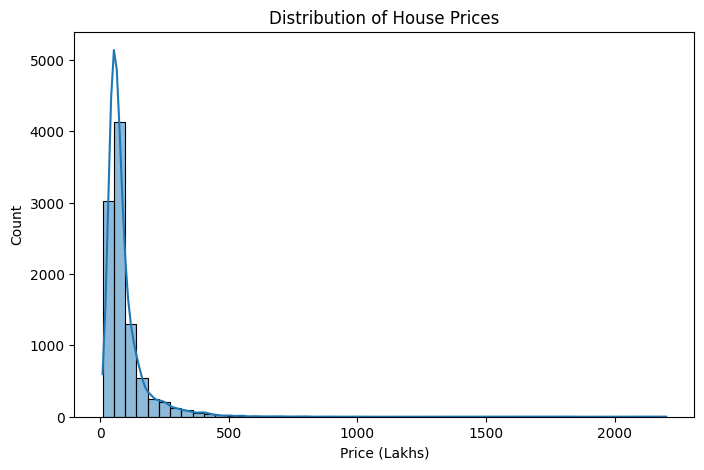

In [42]:
import matplotlib.pyplot as plt
import seaborn as sns

plt.figure(figsize=(8,5))
sns.histplot(df['price'], bins=50, kde=True)

plt.title("Distribution of House Prices")
plt.xlabel("Price (Lakhs)")
plt.ylabel("Count")

plt.show()

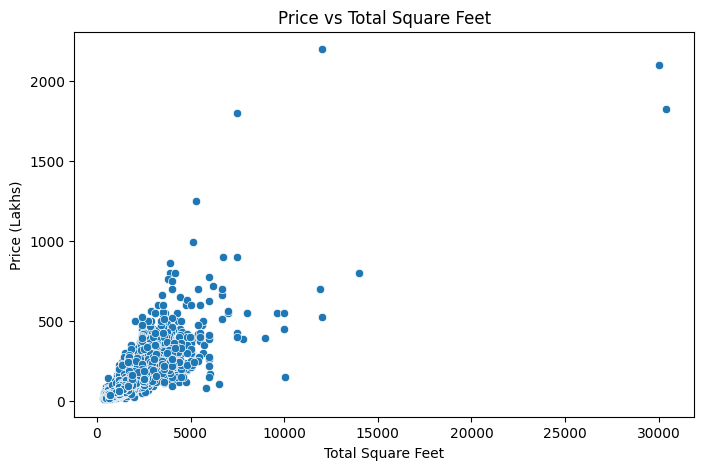

In [43]:
plt.figure(figsize=(8,5))
sns.scatterplot(x=df['total_sqft'], y=df['price'])

plt.title("Price vs Total Square Feet")
plt.xlabel("Total Square Feet")
plt.ylabel("Price (Lakhs)")

plt.show()

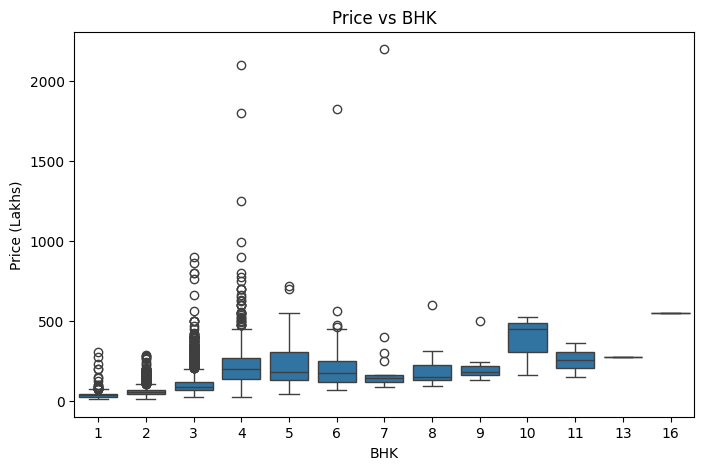

In [44]:
plt.figure(figsize=(8,5))
sns.boxplot(x='bhk', y='price', data=df)

plt.title("Price vs BHK")
plt.xlabel("BHK")
plt.ylabel("Price (Lakhs)")

plt.show()

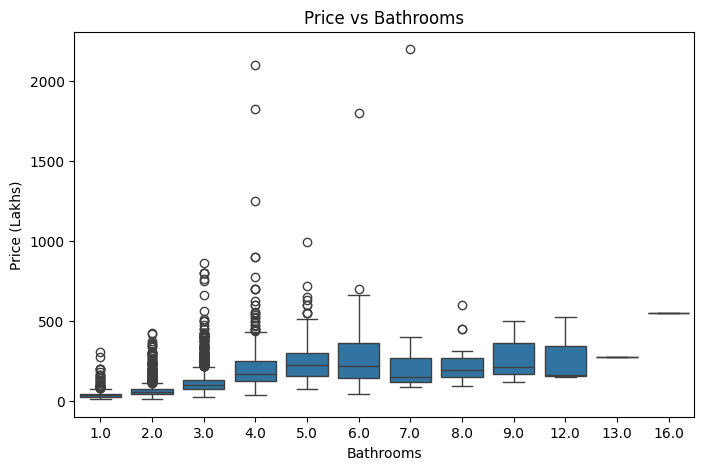

In [45]:
plt.figure(figsize=(8,5))
sns.boxplot(x='bath', y='price', data=df)

plt.title("Price vs Bathrooms")
plt.xlabel("Bathrooms")
plt.ylabel("Price (Lakhs)")

plt.show()

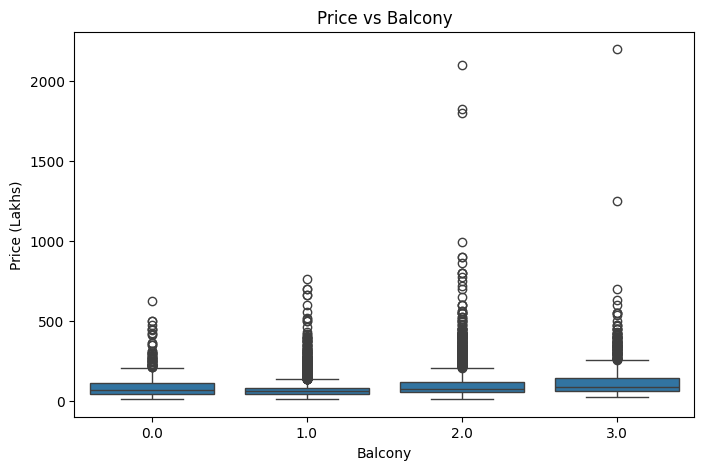

In [46]:
plt.figure(figsize=(8,5))
sns.boxplot(x='balcony', y='price', data=df)

plt.title("Price vs Balcony")
plt.xlabel("Balcony")
plt.ylabel("Price (Lakhs)")

plt.show()

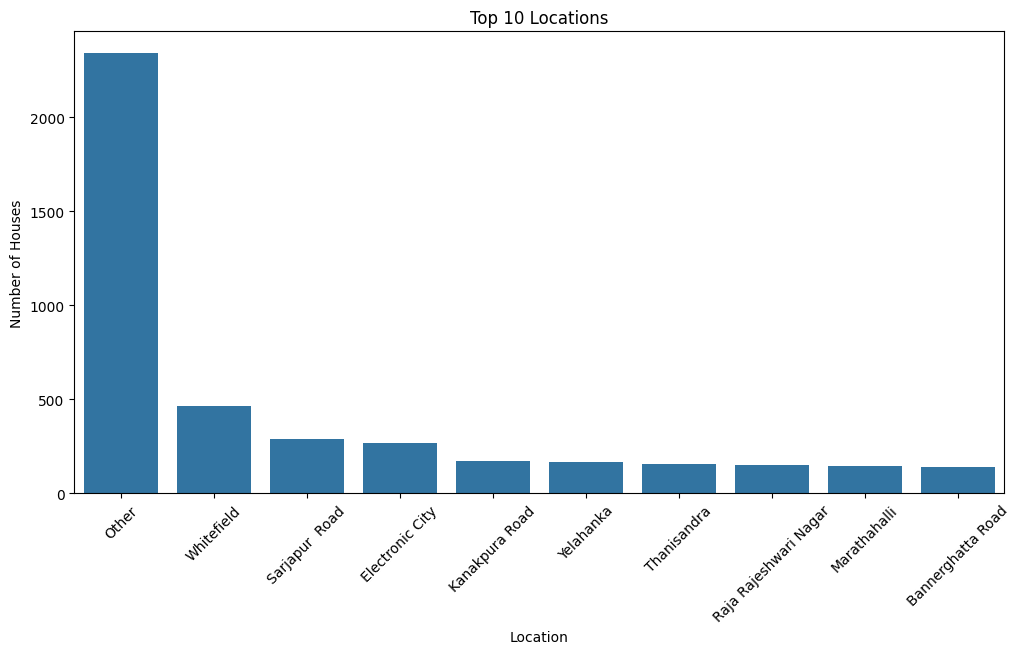

In [47]:
top_locations = df['location'].value_counts().head(10)

plt.figure(figsize=(12,6))
sns.barplot(x=top_locations.index, y=top_locations.values)

plt.title("Top 10 Locations")
plt.xlabel("Location")
plt.ylabel("Number of Houses")

plt.xticks(rotation=45)

plt.show()

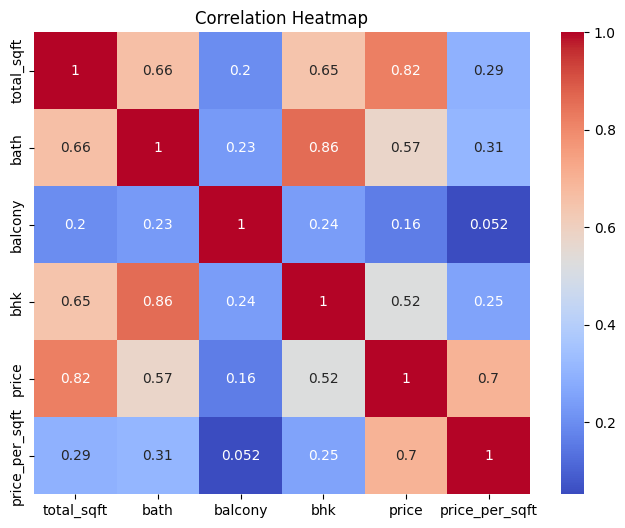

In [48]:
plt.figure(figsize=(8,6))

sns.heatmap(
    df[['total_sqft','bath','balcony','bhk','price','price_per_sqft']].corr(),
    annot=True,
    cmap='coolwarm'
)

plt.title("Correlation Heatmap")

plt.show()

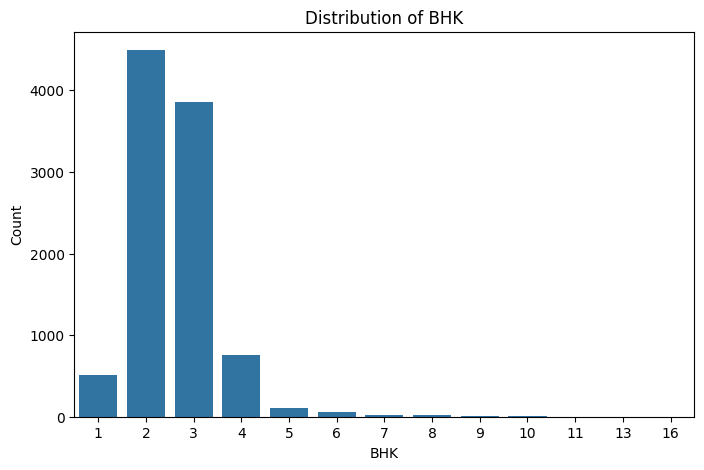

In [49]:
plt.figure(figsize=(8,5))
sns.countplot(x='bhk', data=df)

plt.title("Distribution of BHK")
plt.xlabel("BHK")
plt.ylabel("Count")

plt.show()

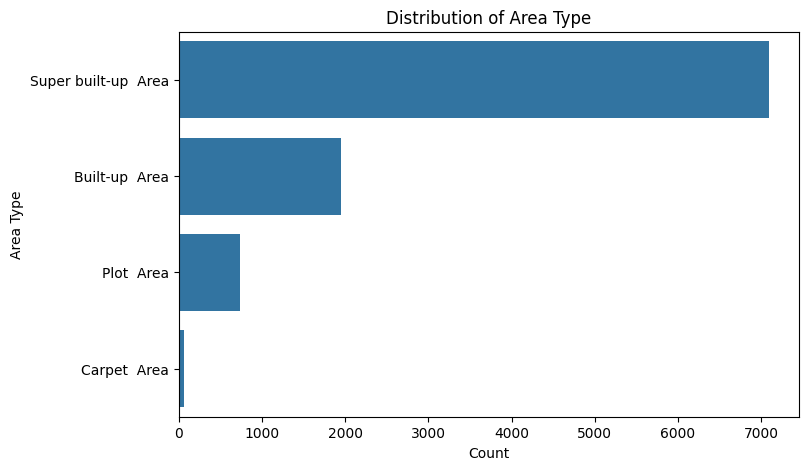

In [50]:
plt.figure(figsize=(8,5))
sns.countplot(y='area_type', data=df)

plt.title("Distribution of Area Type")
plt.xlabel("Count")
plt.ylabel("Area Type")

plt.show()

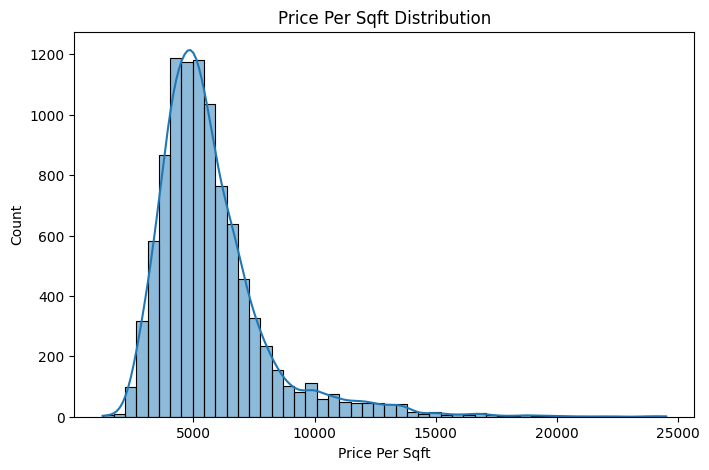

In [51]:
plt.figure(figsize=(8,5))
sns.histplot(df['price_per_sqft'], bins=50, kde=True)

plt.title("Price Per Sqft Distribution")
plt.xlabel("Price Per Sqft")
plt.ylabel("Count")

plt.show()

# ⚙️ Feature Engineering

In [52]:
# Remove unnecessary columns

df = df.drop(['availability', 'size'], axis=1)

df.head()

,area_type,location,total_sqft,bath,balcony,price,bhk,price_per_sqft
0,Super built-up Area,1st Block Jayanagar,2850.0,4.0,1.0,428.0,4,15017.543860
1,Super built-up Area,1st Block Jayanagar,1630.0,3.0,2.0,194.0,3,11901.840491
2,Super built-up Area,1st Block Jayanagar,1875.0,2.0,3.0,235.0,3,12533.333333
3,Built-up Area,1st Block Jayanagar,1200.0,2.0,0.0,130.0,3,10833.333333
4,Super built-up Area,1st Block Jayanagar,1235.0,2.0,2.0,148.0,2,11983.805668


# 🤖 Model Building

In [53]:
# Define features and target

X = df.drop('price', axis=1)
y = df['price']

print(X.shape)
print(y.shape)

(9846, 7)
(9846,)


In [54]:
# Identify categorical and numerical columns

categorical_cols = X.select_dtypes(include=['object']).columns
numerical_cols = X.select_dtypes(exclude=['object']).columns

print("Categorical Columns:")
print(categorical_cols)

print("\nNumerical Columns:")
print(numerical_cols)

Categorical Columns:
Index(['area_type', 'location'], dtype='object')

Numerical Columns:
Index(['total_sqft', 'bath', 'balcony', 'bhk', 'price_per_sqft'], dtype='object')


In [55]:
# Create preprocessing pipeline

preprocessor = ColumnTransformer(
    transformers=[
        ('cat', OneHotEncoder(handle_unknown='ignore'), categorical_cols),
        ('num', StandardScaler(), numerical_cols)
    ]
)

In [56]:
# Split the dataset

X_train, X_test, y_train, y_test = train_test_split(
    X,
    y,
    test_size=0.2,
    random_state=42
)

print(X_train.shape)
print(X_test.shape)

(7876, 7)
(1970, 7)


In [57]:
# Linear Regression Pipeline

lr_pipeline = Pipeline([
    ('preprocessor', preprocessor),
    ('model', LinearRegression())
])

lr_pipeline.fit(X_train, y_train)

lr_pred = lr_pipeline.predict(X_test)

print("Linear Regression Model Trained Successfully")

Linear Regression Model Trained Successfully


In [58]:
# Evaluate Linear Regression

from sklearn.metrics import mean_absolute_error, mean_squared_error, r2_score
import numpy as np

mae = mean_absolute_error(y_test, lr_pred)
rmse = np.sqrt(mean_squared_error(y_test, lr_pred))
r2 = r2_score(y_test, lr_pred)

print("Linear Regression Performance")
print("-----------------------------")
print("MAE :", round(mae,2))
print("RMSE:", round(rmse,2))
print("R²  :", round(r2,4))

Linear Regression Performance
-----------------------------
MAE : 10.76
RMSE: 26.07
R²  : 0.9034


In [59]:
# Decision Tree Pipeline

dt_pipeline = Pipeline([
    ('preprocessor', preprocessor),
    ('model', DecisionTreeRegressor(random_state=42))
])

dt_pipeline.fit(X_train, y_train)

dt_pred = dt_pipeline.predict(X_test)

In [60]:
# Decision Tree Evaluation

dt_mae = mean_absolute_error(y_test, dt_pred)
dt_rmse = np.sqrt(mean_squared_error(y_test, dt_pred))
dt_r2 = r2_score(y_test, dt_pred)

print("Decision Tree Performance")
print("-------------------------")
print("MAE :", round(dt_mae,2))
print("RMSE:", round(dt_rmse,2))
print("R²  :", round(dt_r2,4))

Decision Tree Performance
-------------------------
MAE : 3.22
RMSE: 39.09
R²  : 0.7828


In [61]:
# Random Forest Pipeline

rf_pipeline = Pipeline([
    ('preprocessor', preprocessor),
    ('model', RandomForestRegressor(
        n_estimators=100,
        random_state=42
    ))
])

rf_pipeline.fit(X_train, y_train)

rf_pred = rf_pipeline.predict(X_test)

In [62]:
# Random Forest Evaluation

rf_mae = mean_absolute_error(y_test, rf_pred)
rf_rmse = np.sqrt(mean_squared_error(y_test, rf_pred))
rf_r2 = r2_score(y_test, rf_pred)

print("Random Forest Performance")
print("-------------------------")
print("MAE :", round(rf_mae,2))
print("RMSE:", round(rf_rmse,2))
print("R²  :", round(rf_r2,4))

Random Forest Performance
-------------------------
MAE : 1.79
RMSE: 21.99
R²  : 0.9313


In [63]:
# Model Comparison

comparison = pd.DataFrame({
    'Model': [
        'Linear Regression',
        'Decision Tree',
        'Random Forest'
    ],
    'MAE': [
        mae,
        dt_mae,
        rf_mae
    ],
    'RMSE': [
        rmse,
        dt_rmse,
        rf_rmse
    ],
    'R2 Score': [
        r2,
        dt_r2,
        rf_r2
    ]
})

comparison.sort_values(by='R2 Score', ascending=False)

,Model,MAE,RMSE,R2 Score
2,Random Forest,1.794516,21.991998,0.931258
0,Linear Regression,10.759607,26.065900,0.903431
1,Decision Tree,3.217266,39.092962,0.782784


# 📈 Feature Importance

In [64]:
# Get feature names after encoding

feature_names = preprocessor.get_feature_names_out()

# Get feature importance from Random Forest

importance = rf_pipeline.named_steps['model'].feature_importances_

feature_importance = pd.DataFrame({
    'Feature': feature_names,
    'Importance': importance
})

feature_importance = feature_importance.sort_values(
    by='Importance',
    ascending=False
)

feature_importance.head(10)

,Feature,Importance
238,num__total_sqft,0.716703
242,num__price_per_sqft,0.272974
239,num__bath,0.003456
240,num__balcony,0.001481
241,num__bhk,0.001439
67,cat__location_Cunningham Road,0.001307
166,cat__location_Malleshwaram,0.001060
184,cat__location_Other,0.000239
0,cat__area_type_Built-up Area,0.000236
3,cat__area_type_Super built-up Area,0.000172


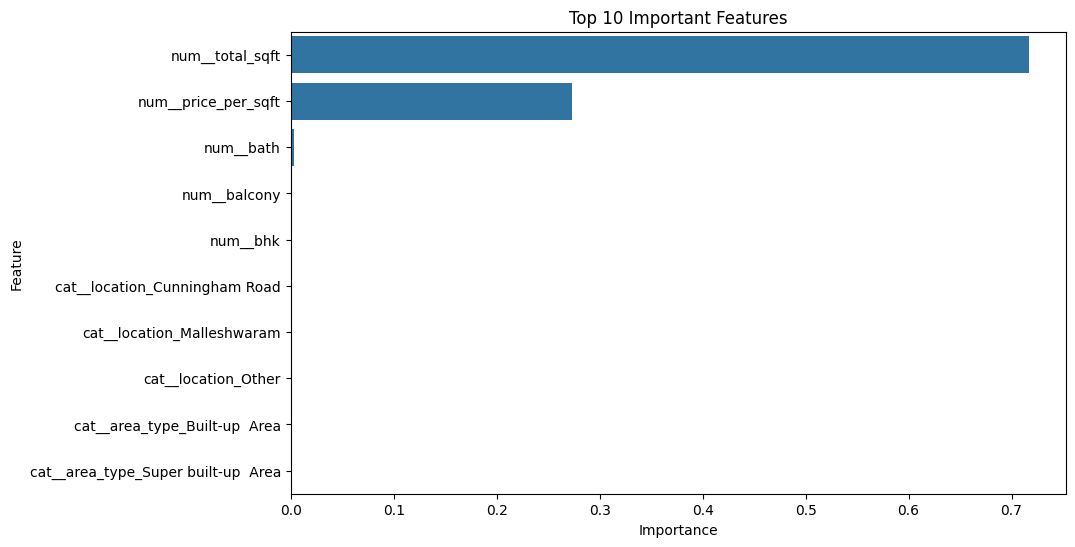

In [65]:
# Top 10 Important Features

plt.figure(figsize=(10,6))

sns.barplot(
    data=feature_importance.head(10),
    x='Importance',
    y='Feature'
)

plt.title("Top 10 Important Features")

plt.show()

# ✅ Conclusion

In [66]:
print("Best Model : Random Forest")
print("R² Score :", round(rf_r2,4))
print("RMSE :", round(rf_rmse,2))
print("MAE :", round(rf_mae,2))

Best Model : Random Forest
R² Score : 0.9313
RMSE : 21.99
MAE : 1.79


In [67]:
# Save cleaned dataset

df.to_csv("Cleaned_Bangalore_House_Data.csv", index=False)

In [68]:
# Check final dataset

df.info()

<class 'pandas.core.frame.DataFrame'>
Index: 9846 entries, 0 to 9849
Data columns (total 8 columns):
 #   Column          Non-Null Count  Dtype  
---  ------          --------------  -----  
 0   area_type       9846 non-null   object 
 1   location        9846 non-null   object 
 2   total_sqft      9846 non-null   float64
 3   bath            9846 non-null   float64
 4   balcony         9846 non-null   float64
 5   price           9846 non-null   float64
 6   bhk             9846 non-null   int64  
 7   price_per_sqft  9846 non-null   float64
dtypes: float64(5), int64(1), object(2)
memory usage: 692.3+ KB


In [69]:
# Final dataset shape

df.shape

(9846, 8)

In [70]:
# Save final cleaned dataset

df.to_csv("Final_Cleaned_Bangalore_House_Data.csv", index=False)

print("Dataset Saved Successfully")

Dataset Saved Successfully
